### Notebook setup and configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import cv2 

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import yaml 

from src.logger.custom_logger import logger 
from src.utils.io import ImageLoader

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name  == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent 

DATA_DIR = PROJECT_ROOT / "data" / "raw"
THRESHOLDS_PATH = PROJECT_ROOT / "config" / "thresholds.yaml"

with THRESHOLDS_PATH.open() as f:
    thresholds = yaml.safe_load(f)

print(thresholds)
print(yaml.safe_dump(thresholds['quality'],default_flow_style=False))
# Converts the python dict or list into YAML string


{'quality': {'min_aspect_ratio': 1.3, 'min_width': 50, 'min_height': 100, 'min_brightness': 15.0, 'max_brightness': 240.0, 'min_blur_variance': 80.0}, 'person_detection': {'min_confidence': 0.5, 'min_bbox_area_ratio': 0.4, 'max_persons': 5}, 'pose': {'keypoint_confidence': 0.5, 'min_head_kpts': 1, 'min_torso_kpts': 4, 'min_leg_kpts': 4}, 'face': {'min_detection_confidence': 0.6, 'min_landmarks_frontal': 4, 'min_landmarks_profile': 2, 'min_face_area_ratio': 0.005}, 'age': {'min_age': 16, 'age_confidence': 0.5}, 'clip_ad_filter': {'similarity_margin': 0.05, 'real_person_prompts': ['a candid photograph of a person walking on the street', 'a snapshot of a pedestrian', 'a photo of a person in a public place', 'a street photograph of someone'], 'ad_prompts': ['an advertisement photo of clothing', 'a mannequin in a store window display', 'a clothing product photograph on a hanger', 'a fashion magazine cover', 'a billboard advertisement with a person']}}
max_brightness: 240.0
min_aspect_ratio:

### Examining the dataset

In [3]:
all_files = sorted(DATA_DIR.glob("*"))
# gets all files and folders inside the directory this returns us an iterator
all_files =  [p for p in all_files if p.is_file()]

total_files = len(all_files)
print(f"Total files present: {total_files}")

sizes_kb = np.array([p.stat().st_size for p in all_files]) / 1024.0 
# stat retrieves file metadata from os 
print(f"File sizes (KB): min:{sizes_kb.min():.1f} median:{np.median(sizes_kb):.1f} "
      f"mean: {sizes_kb.mean():.1f} max:{sizes_kb.max():.1f}")


Total files present: 1148
File sizes (KB): min:0.0 median:129.1 mean: 256.0 max:2544.7


### Inspecting image properties

In [4]:
loader = ImageLoader()

records: list[dict] = []
load_errors: list[tuple[Path,str]] = []

candidates = [p for p in all_files if p.suffix.lower() in loader.SUPPORTED_EXTENSIONS] 
print(f"Loadable candidates: {len(candidates):,} / {len(all_files):,}")

for path in candidates:
    try:
        crop = loader.load(path)
    
    except Exception as e:
        load_errors.append((path,str(e)))
        continue

    gray = cv2.cvtColor(crop.image,cv2.COLOR_RGB2GRAY)
    brightness = float(gray.mean()) # avg pixel intensity
    blur_variance = float(cv2.Laplacian(gray,cv2.CV_64F).var()) 
    # blur detection with laplacian

    records.append({"crop_id":crop.crop_id,
                    "width":crop.width,
                    "height":crop.height,
                    "aspect":crop.height / crop.width,
                    "brightness":brightness,
                    "blur_variance":blur_variance,
                    "size_kb":path.stat().st_size / 1024.0})
try:
    df = pd.DataFrame.from_records(records)
    print(f"Loaded successfully: {len(df):,}")
except Exception as e:
    if load_errors:
        print("Failed to load")
    print(str(e))

df.describe().round(2)


2026-05-09 11:56:05.441 | INFO     | src.utils.io:load:61 - Loaded crop (1).png | shape: ((211, 416, 3)) | bytes: 263328
2026-05-09 11:56:05.446 | INFO     | src.utils.io:load:61 - Loaded crop (10).png | shape: ((283, 719, 3)) | bytes: 610431
2026-05-09 11:56:05.454 | INFO     | src.utils.io:load:61 - Loaded crop (100).png | shape: ((111, 849, 3)) | bytes: 282717
2026-05-09 11:56:05.459 | INFO     | src.utils.io:load:61 - Loaded crop (1000).png | shape: ((198, 696, 3)) | bytes: 413424
2026-05-09 11:56:05.464 | INFO     | src.utils.io:load:61 - Loaded crop (1001).png | shape: ((220, 641, 3)) | bytes: 423060
2026-05-09 11:56:05.469 | INFO     | src.utils.io:load:61 - Loaded crop (1002).png | shape: ((138, 1005, 3)) | bytes: 416070
2026-05-09 11:56:05.474 | INFO     | src.utils.io:load:61 - Loaded crop (1003).png | shape: ((196, 504, 3)) | bytes: 296352
2026-05-09 11:56:05.478 | INFO     | src.utils.io:load:61 - Loaded crop (1004).png | shape: ((221, 512, 3)) | bytes: 339456
2026-05-09 11

Loadable candidates: 1,147 / 1,148


2026-05-09 11:56:05.535 | INFO     | src.utils.io:load:61 - Loaded crop (1014).png | shape: ((127, 1256, 3)) | bytes: 478536
2026-05-09 11:56:05.543 | INFO     | src.utils.io:load:61 - Loaded crop (1015).png | shape: ((206, 781, 3)) | bytes: 482658
2026-05-09 11:56:05.558 | INFO     | src.utils.io:load:61 - Loaded crop (1016).png | shape: ((122, 1424, 3)) | bytes: 521184
2026-05-09 11:56:05.571 | INFO     | src.utils.io:load:61 - Loaded crop (1017).png | shape: ((219, 815, 3)) | bytes: 535455
2026-05-09 11:56:05.579 | INFO     | src.utils.io:load:61 - Loaded crop (1018).png | shape: ((183, 870, 3)) | bytes: 477630
2026-05-09 11:56:05.584 | INFO     | src.utils.io:load:61 - Loaded crop (1019).png | shape: ((265, 619, 3)) | bytes: 492105
2026-05-09 11:56:05.589 | INFO     | src.utils.io:load:61 - Loaded crop (102).png | shape: ((145, 444, 3)) | bytes: 193140
2026-05-09 11:56:05.596 | INFO     | src.utils.io:load:61 - Loaded crop (1020).png | shape: ((265, 619, 3)) | bytes: 492105
2026-05

Loaded successfully: 1,147


,width,height,aspect,brightness,blur_variance,size_kb
count,1147.00,1147.00,1147.00,1147.00,1147.00,1147.00
mean,267.26,788.29,3.46,102.88,150.00,256.25
std,187.91,449.65,2.19,45.70,292.07,290.83
min,30.00,86.00,1.80,2.93,0.38,5.53
25%,133.00,431.50,2.28,67.64,17.27,71.60
50%,206.00,685.00,2.79,106.86,49.04,129.10
75%,339.00,1092.50,3.68,137.74,138.26,339.87
max,1157.00,2158.00,31.90,239.25,2628.72,2544.74


The dataset primarly contains a tall person's full body crop which is reflected from the median aspect ratio of 2.79. Median brightness (~107) suggests overall good exposure quality. However the dataset contains several problematic samples:

- extremely small crops min_width = 30px
- unusually high aspect ratio max = 2.93 
- very dark images (brightness min) = 2.93 
- and high blurry crops (blur variance min = 0.38) 

These indicate we need additional filtering before training 

In [5]:
df.head()

,crop_id,width,height,aspect,brightness,blur_variance,size_kb
0,crop (1),211,416,1.971564,168.199952,47.824523,116.637695
1,crop (10),283,719,2.540636,9.351917,33.475400,115.519531
2,crop (100),111,849,7.648649,115.394985,16.001127,94.526367
3,crop (1000),198,696,3.515152,156.354442,68.698277,167.729492
4,crop (1001),220,641,2.913636,90.778790,169.305194,167.254883


#### Plotting image characterstic distributions

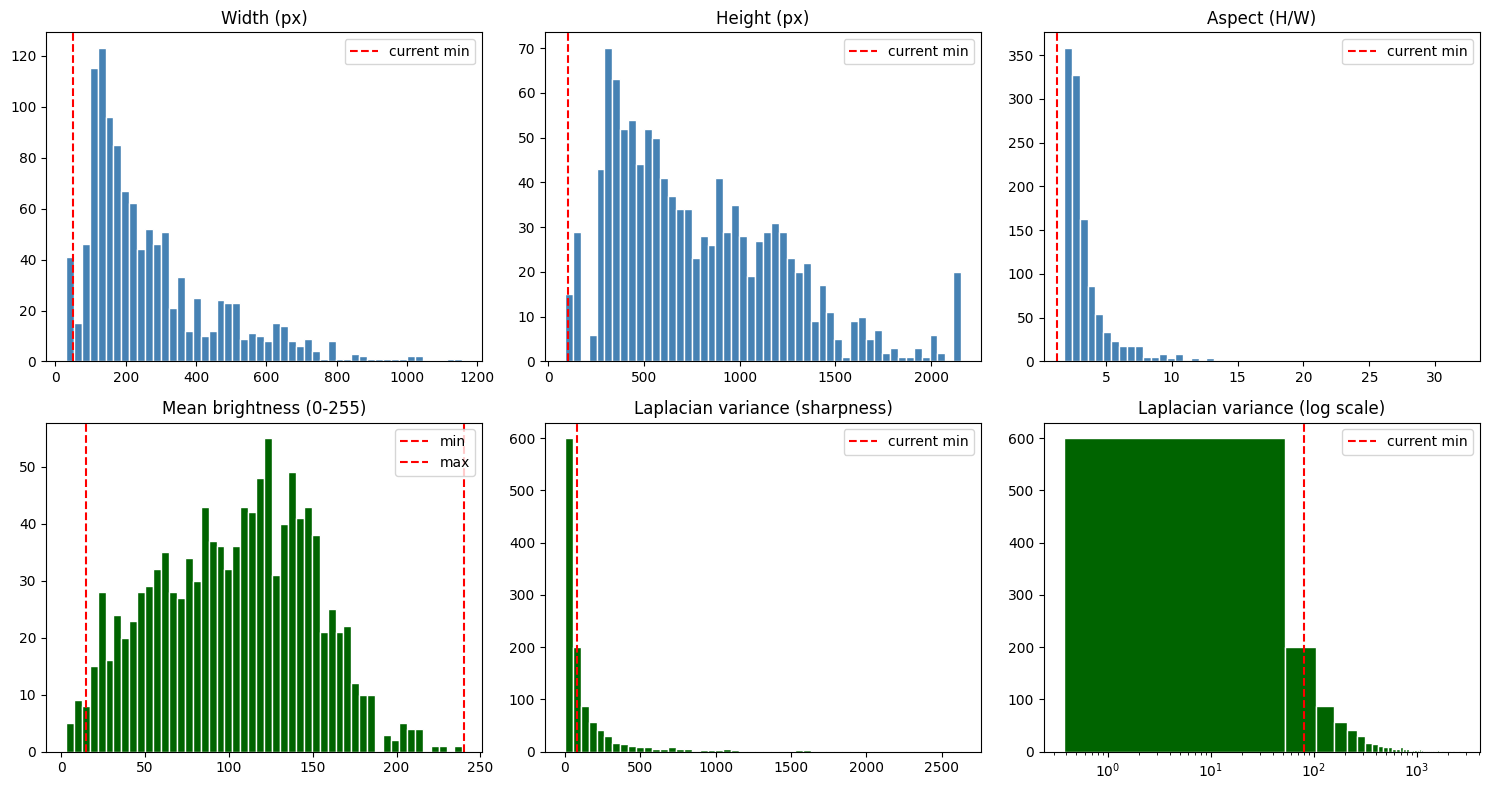

In [6]:
fig,axes = plt.subplots(2,3,figsize=(15,8))

axes[0,0].hist(df['width'],bins=50,color="steelblue",edgecolor="white")
axes[0,0].set_title("Width (px)")
axes[0,0].axvline(thresholds["quality"]["min_width"], color="red", linestyle="--", label="current min")
axes[0,0].legend()

axes[0,1].hist(df['height'],bins=50,color="steelblue",edgecolor="white")
axes[0,1].set_title("Height (px)")
axes[0,1].axvline(thresholds['quality']['min_height'],color="red",linestyle="--",label="current min")
axes[0,1].legend()

axes[0,2].hist(df['aspect'],bins=50,color="steelblue",edgecolor="white")
axes[0,2].set_title("Aspect (H/W)")
axes[0,2].axvline(thresholds['quality']['min_aspect_ratio'],color="red",linestyle="--",label="current min")
axes[0,2].legend()

axes[1,0].hist(df['brightness'],bins=50,color="darkgreen",edgecolor="white")
axes[1,0].set_title("Mean brightness (0-255)")
axes[1,0].axvline(thresholds['quality']['min_brightness'],color="red",linestyle="--",label="min")
axes[1,0].axvline(thresholds['quality']['max_brightness'],color="red",linestyle="--",label="max")
axes[1,0].legend()

axes[1,1].hist(df["blur_variance"],bins=50,color="darkgreen",edgecolor="white")
axes[1,1].set_title("Laplacian variance (sharpness)")
axes[1,1].axvline(thresholds['quality']['min_blur_variance'],color="red",linestyle="--",label="current min")
axes[1,1].legend()

# log scale variant of blur 
axes[1,2].hist(df['blur_variance'],bins=50,color="darkgreen",edgecolor="white")
axes[1,2].set_xscale("log")
axes[1,2].set_title("Laplacian variance (log scale)")
axes[1,2].axvline(thresholds["quality"]["min_blur_variance"],color="red",linestyle="--",label="current min")
axes[1,2].legend()

plt.tight_layout()
plt.show()

1. `Width(px) distribution`: Most images have width approximately between 100-350 px. There is a longtail extending towards 1000+ px and current threshold is around 60px.

2. `Height(px) distribution`: Most images have height approximately 300-1300px and threshold is approximately 100px filters extremely small detections.

3. `Aspect ratio (height/width)`: The aspect-ratio distribution strongly confirms that most crops are tall human figures, concentrated around ratios of 2–4. Extremely large aspect ratios form a sparse long tail and likely correspond to invalid or overly narrow crops.

4. `Mean brightness`:  Brightness values form a smooth unimodal distribution centered around 110-140 generally well-exposed images. The current thresholds lie outside the main mass and it removes extreme underexposed or overexposed samples.

5. `Laplacian variance`:  This distribution is heavily skewed, most values lie between 0-100. Then there is a long massive tails 100-2500+. Threshold is approximately around 50. 

6. `Laplacian variance (log scale)`: The distribution mainly lies between 10-100 and threshold approximately around 50 it cuts into main distribution, blur threshold maybe too aggresive rejecting acceptable images. 

### Diplay images and their metrics

2026-05-09 11:56:15.511 | INFO     | src.utils.io:load:61 - Loaded crop (707).png | shape: ((833, 2146, 3)) | bytes: 5362854
2026-05-09 11:56:15.523 | INFO     | src.utils.io:load:61 - Loaded crop (198).png | shape: ((277, 885, 3)) | bytes: 735435
2026-05-09 11:56:15.534 | INFO     | src.utils.io:load:61 - Loaded crop (262).png | shape: ((349, 956, 3)) | bytes: 1000932
2026-05-09 11:56:15.544 | INFO     | src.utils.io:load:61 - Loaded crop (48).png | shape: ((379, 1057, 3)) | bytes: 1201809
2026-05-09 11:56:15.556 | INFO     | src.utils.io:load:61 - Loaded crop (944).png | shape: ((642, 1348, 3)) | bytes: 2596248
2026-05-09 11:56:15.566 | INFO     | src.utils.io:load:61 - Loaded crop (376).png | shape: ((171, 805, 3)) | bytes: 412965
2026-05-09 11:56:15.573 | INFO     | src.utils.io:load:61 - Loaded crop (13).png | shape: ((338, 624, 3)) | bytes: 632736
2026-05-09 11:56:15.580 | INFO     | src.utils.io:load:61 - Loaded crop (10).png | shape: ((283, 719, 3)) | bytes: 610431


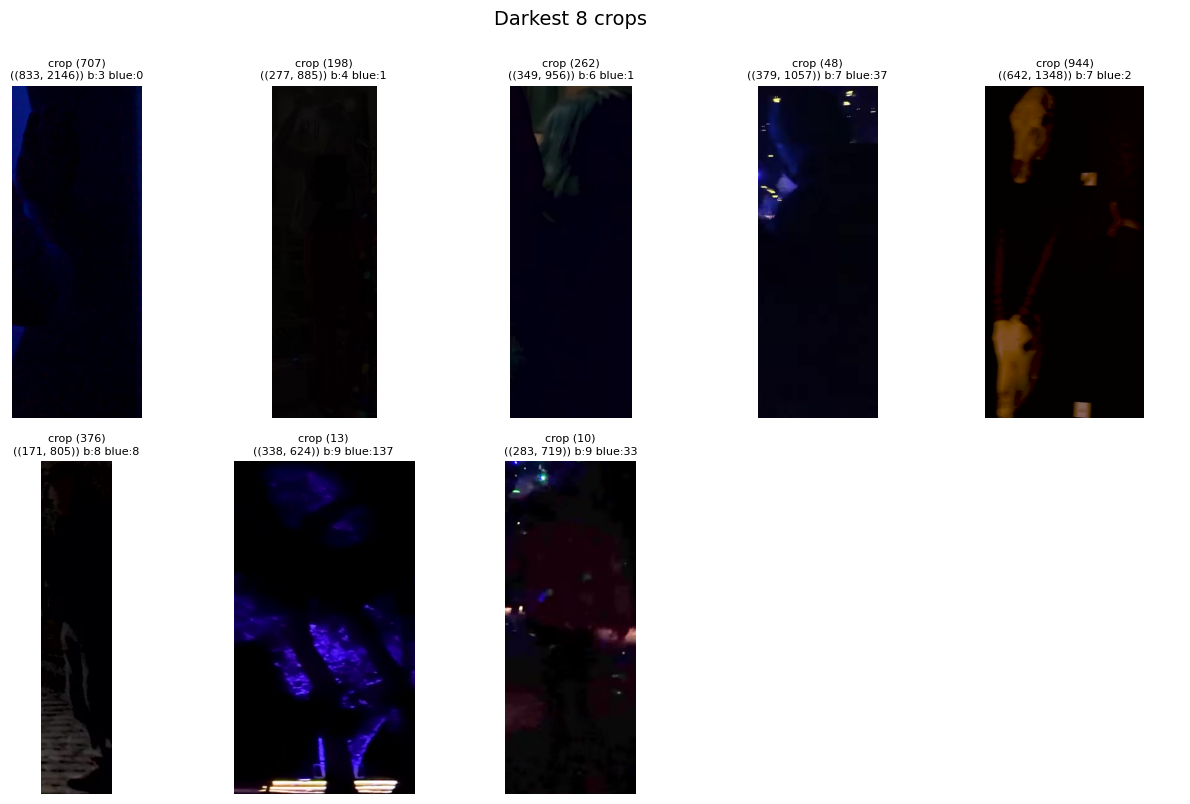

2026-05-09 11:56:15.903 | INFO     | src.utils.io:load:61 - Loaded crop (468).png | shape: ((184, 337, 3)) | bytes: 186024
2026-05-09 11:56:15.909 | INFO     | src.utils.io:load:61 - Loaded crop (98).png | shape: ((220, 399, 3)) | bytes: 263340
2026-05-09 11:56:15.915 | INFO     | src.utils.io:load:61 - Loaded crop (141).png | shape: ((223, 422, 3)) | bytes: 282318
2026-05-09 11:56:15.921 | INFO     | src.utils.io:load:61 - Loaded crop (96).png | shape: ((172, 511, 3)) | bytes: 263676
2026-05-09 11:56:15.928 | INFO     | src.utils.io:load:61 - Loaded crop (97).png | shape: ((172, 511, 3)) | bytes: 263676
2026-05-09 11:56:15.937 | INFO     | src.utils.io:load:61 - Loaded crop (853).png | shape: ((199, 1176, 3)) | bytes: 702072
2026-05-09 11:56:15.943 | INFO     | src.utils.io:load:61 - Loaded crop (411).png | shape: ((126, 372, 3)) | bytes: 140616
2026-05-09 11:56:15.957 | INFO     | src.utils.io:load:61 - Loaded crop (708).png | shape: ((650, 1187, 3)) | bytes: 2314650


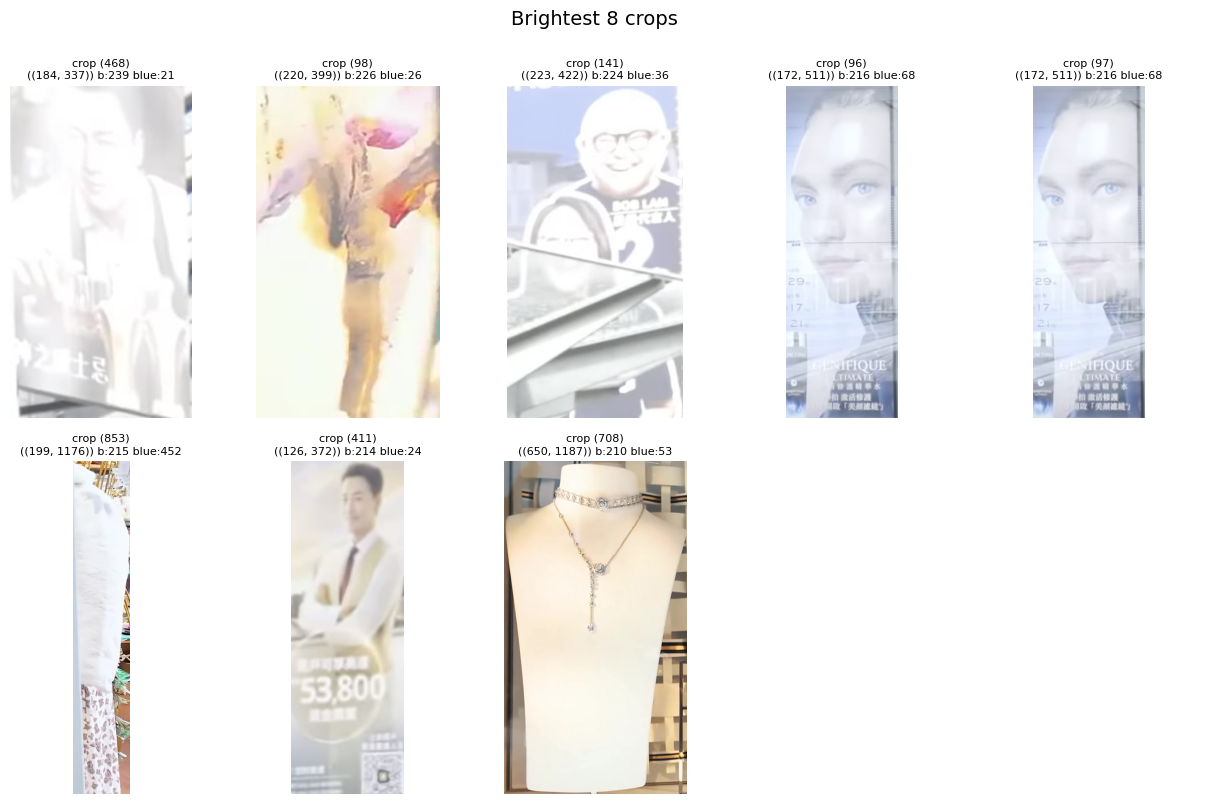

2026-05-09 11:56:16.243 | INFO     | src.utils.io:load:61 - Loaded crop (707).png | shape: ((833, 2146, 3)) | bytes: 5362854
2026-05-09 11:56:16.257 | INFO     | src.utils.io:load:61 - Loaded crop (262).png | shape: ((349, 956, 3)) | bytes: 1000932
2026-05-09 11:56:16.268 | INFO     | src.utils.io:load:61 - Loaded crop (198).png | shape: ((277, 885, 3)) | bytes: 735435
2026-05-09 11:56:16.278 | INFO     | src.utils.io:load:61 - Loaded crop (78).png | shape: ((369, 894, 3)) | bytes: 989658
2026-05-09 11:56:16.287 | INFO     | src.utils.io:load:61 - Loaded crop (121).png | shape: ((311, 978, 3)) | bytes: 912474
2026-05-09 11:56:16.297 | INFO     | src.utils.io:load:61 - Loaded crop (122).png | shape: ((311, 978, 3)) | bytes: 912474
2026-05-09 11:56:16.307 | INFO     | src.utils.io:load:61 - Loaded crop (1035).png | shape: ((506, 1080, 3)) | bytes: 1639440
2026-05-09 11:56:16.318 | INFO     | src.utils.io:load:61 - Loaded crop (1036).png | shape: ((506, 1080, 3)) | bytes: 1639440


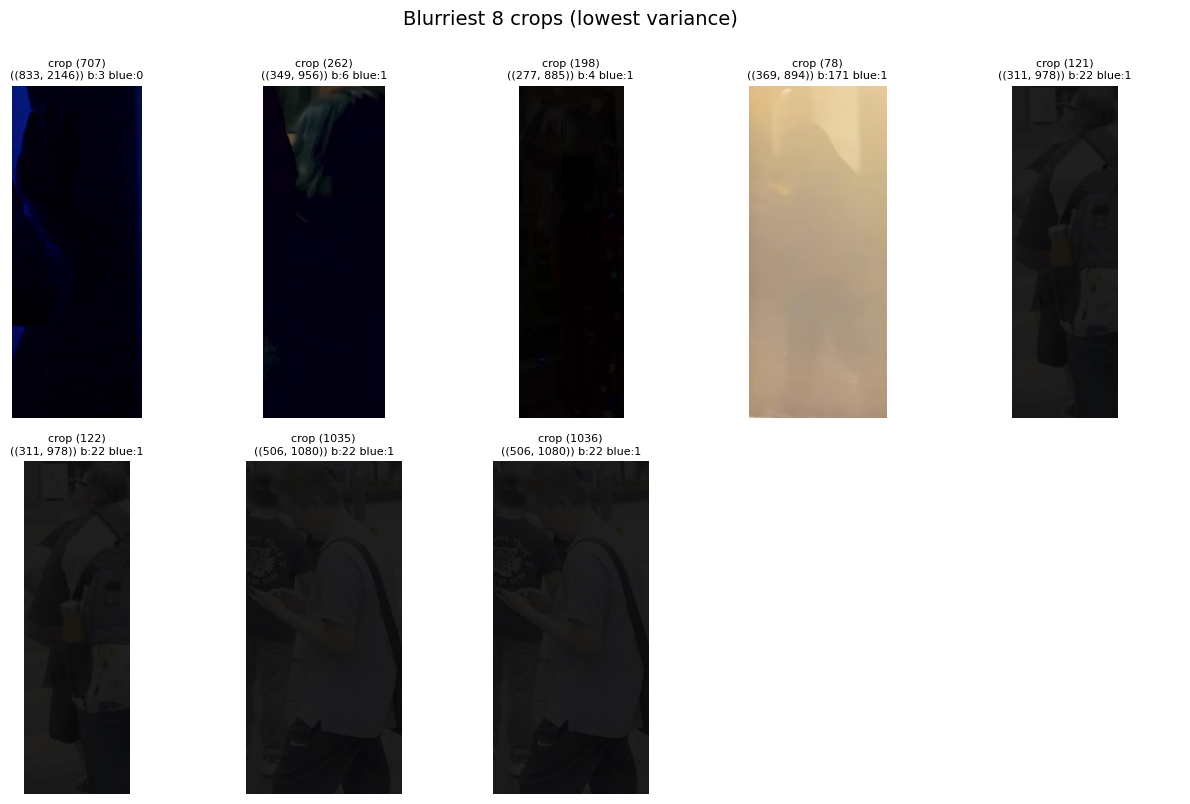

2026-05-09 11:56:16.715 | INFO     | src.utils.io:load:61 - Loaded crop (68).png | shape: ((99, 473, 3)) | bytes: 140481
2026-05-09 11:56:16.721 | INFO     | src.utils.io:load:61 - Loaded crop (340).png | shape: ((110, 295, 3)) | bytes: 97350
2026-05-09 11:56:16.726 | INFO     | src.utils.io:load:61 - Loaded crop (384).png | shape: ((95, 258, 3)) | bytes: 73530
2026-05-09 11:56:16.730 | INFO     | src.utils.io:load:61 - Loaded crop (394).png | shape: ((94, 283, 3)) | bytes: 79806
2026-05-09 11:56:16.736 | INFO     | src.utils.io:load:61 - Loaded crop (310).png | shape: ((99, 380, 3)) | bytes: 112860
2026-05-09 11:56:16.742 | INFO     | src.utils.io:load:61 - Loaded crop (1028).png | shape: ((173, 507, 3)) | bytes: 263133
2026-05-09 11:56:16.747 | INFO     | src.utils.io:load:61 - Loaded crop (1029).png | shape: ((173, 507, 3)) | bytes: 263133
2026-05-09 11:56:16.752 | INFO     | src.utils.io:load:61 - Loaded crop (93).png | shape: ((134, 384, 3)) | bytes: 154368


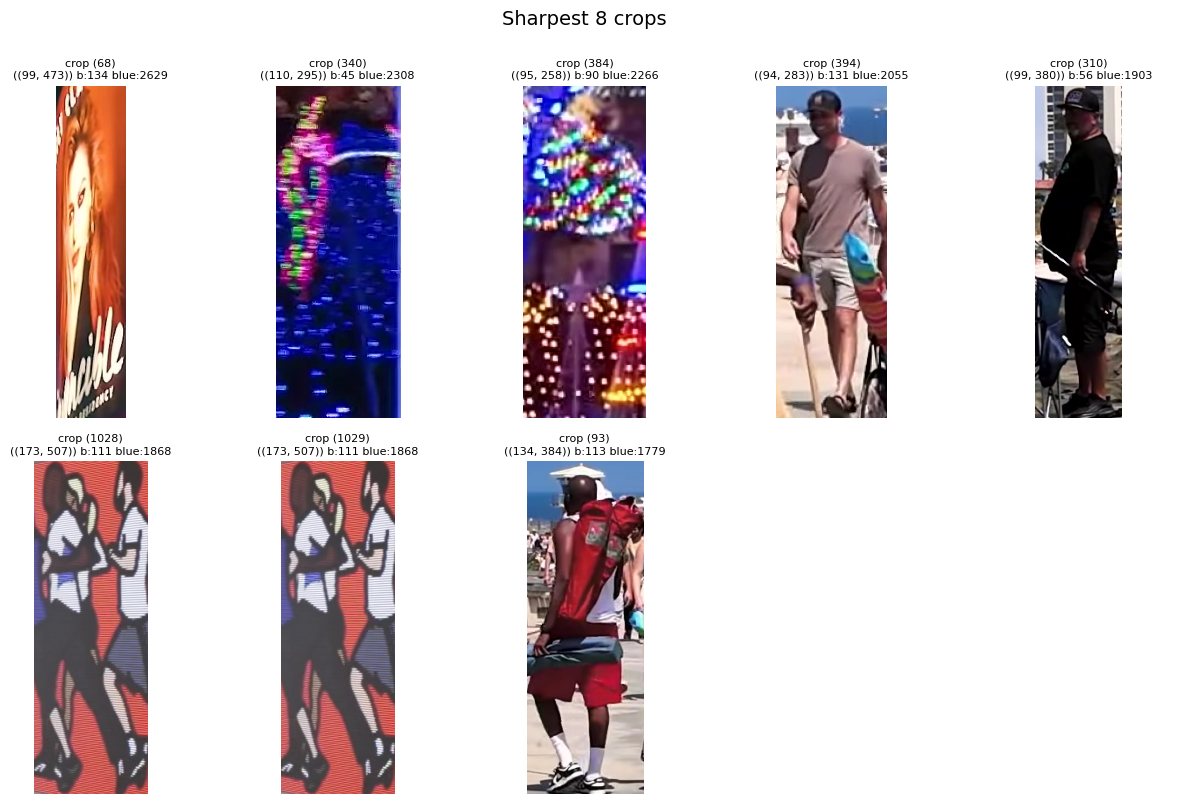

2026-05-09 11:56:16.978 | INFO     | src.utils.io:load:61 - Loaded crop (541).png | shape: ((30, 86, 3)) | bytes: 7740
2026-05-09 11:56:16.982 | INFO     | src.utils.io:load:61 - Loaded crop (528).png | shape: ((37, 137, 3)) | bytes: 15207
2026-05-09 11:56:16.989 | INFO     | src.utils.io:load:61 - Loaded crop (524).png | shape: ((38, 136, 3)) | bytes: 15504
2026-05-09 11:56:16.996 | INFO     | src.utils.io:load:61 - Loaded crop (533).png | shape: ((38, 126, 3)) | bytes: 14364
2026-05-09 11:56:17.006 | INFO     | src.utils.io:load:61 - Loaded crop (534).png | shape: ((38, 118, 3)) | bytes: 13452
2026-05-09 11:56:17.012 | INFO     | src.utils.io:load:61 - Loaded crop (535).png | shape: ((39, 123, 3)) | bytes: 14391
2026-05-09 11:56:17.017 | INFO     | src.utils.io:load:61 - Loaded crop (540).png | shape: ((39, 94, 3)) | bytes: 10998
2026-05-09 11:56:17.024 | INFO     | src.utils.io:load:61 - Loaded crop (256).png | shape: ((40, 1276, 3)) | bytes: 153120


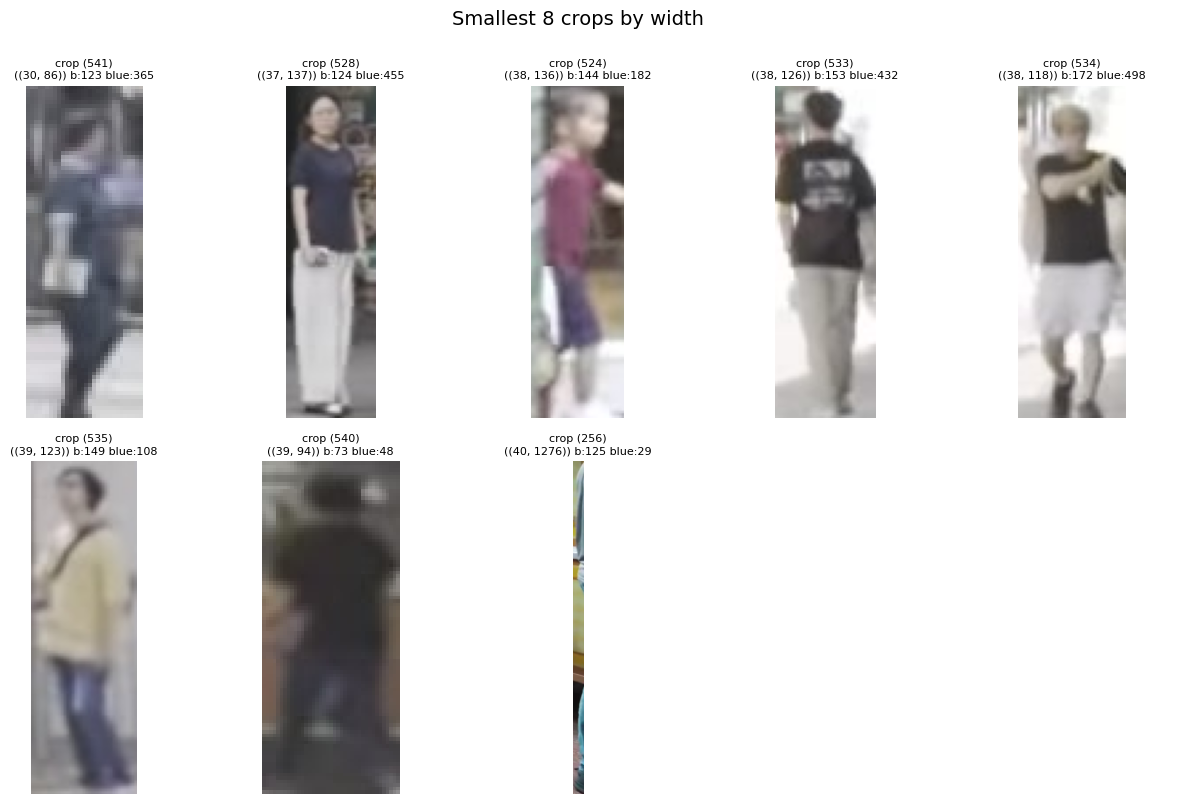

In [7]:
def show_grid(crop_df: pd.DataFrame,
              title: str,
              n_cols: int = 5) -> None:
    """Display grid of crop imgs with their metrics"""
    n = len(crop_df)
    n_rows = (n + n_cols - 1) // n_cols # how many rows are needed 
    
    fig,axes = plt.subplots(n_rows,n_cols,figsize=(n_cols*2.5,n_rows*4))
    axes = np.atleast_2d(axes).flatten() # atleast converts list into 2d np array 

    for ax,(_,row) in zip(axes,crop_df.iterrows()):
        path = next(DATA_DIR.rglob(f"{row['crop_id']}.*"))
        img = loader.load(path).image

        ax.imshow(img)
        ax.set_title(f"{row['crop_id'][:20]}\n"
                     f"({row['width'],row['height']}) "
                     f"b:{row['brightness']:.0f} "
                     f"blue:{row['blur_variance']:.0f}",
                     fontsize=8)
        ax.axis('off')
    
    for ax in axes[len(crop_df):]:
        ax.axis("off")
    
    fig.suptitle(title,fontsize=14,y=1.0)
    plt.tight_layout()
    plt.show()

show_grid(df.nsmallest(8,"brightness"),"Darkest 8 crops")

show_grid(df.nlargest(8, "brightness"), "Brightest 8 crops")

show_grid(df.nsmallest(8, "blur_variance"), "Blurriest 8 crops (lowest variance)")

show_grid(df.nlargest(8, "blur_variance"), "Sharpest 8 crops")

show_grid(df.nsmallest(8, "width"), "Smallest 8 crops by width")




### Random sampling 

2026-05-09 11:56:17.275 | INFO     | src.utils.io:load:61 - Loaded crop (241).png | shape: ((190, 449, 3)) | bytes: 255930
2026-05-09 11:56:17.283 | INFO     | src.utils.io:load:61 - Loaded crop (968).png | shape: ((290, 556, 3)) | bytes: 483720
2026-05-09 11:56:17.299 | INFO     | src.utils.io:load:61 - Loaded crop (736).png | shape: ((352, 1941, 3)) | bytes: 2049696
2026-05-09 11:56:17.305 | INFO     | src.utils.io:load:61 - Loaded crop (352).png | shape: ((73, 559, 3)) | bytes: 122421
2026-05-09 11:56:17.313 | INFO     | src.utils.io:load:61 - Loaded crop (991).png | shape: ((379, 685, 3)) | bytes: 778845
2026-05-09 11:56:17.320 | INFO     | src.utils.io:load:61 - Loaded crop (1095).png | shape: ((225, 649, 3)) | bytes: 438075
2026-05-09 11:56:17.333 | INFO     | src.utils.io:load:61 - Loaded crop (726)(1).png | shape: ((460, 1472, 3)) | bytes: 2031360
2026-05-09 11:56:17.342 | INFO     | src.utils.io:load:61 - Loaded crop (98).png | shape: ((220, 399, 3)) | bytes: 263340
2026-05-09

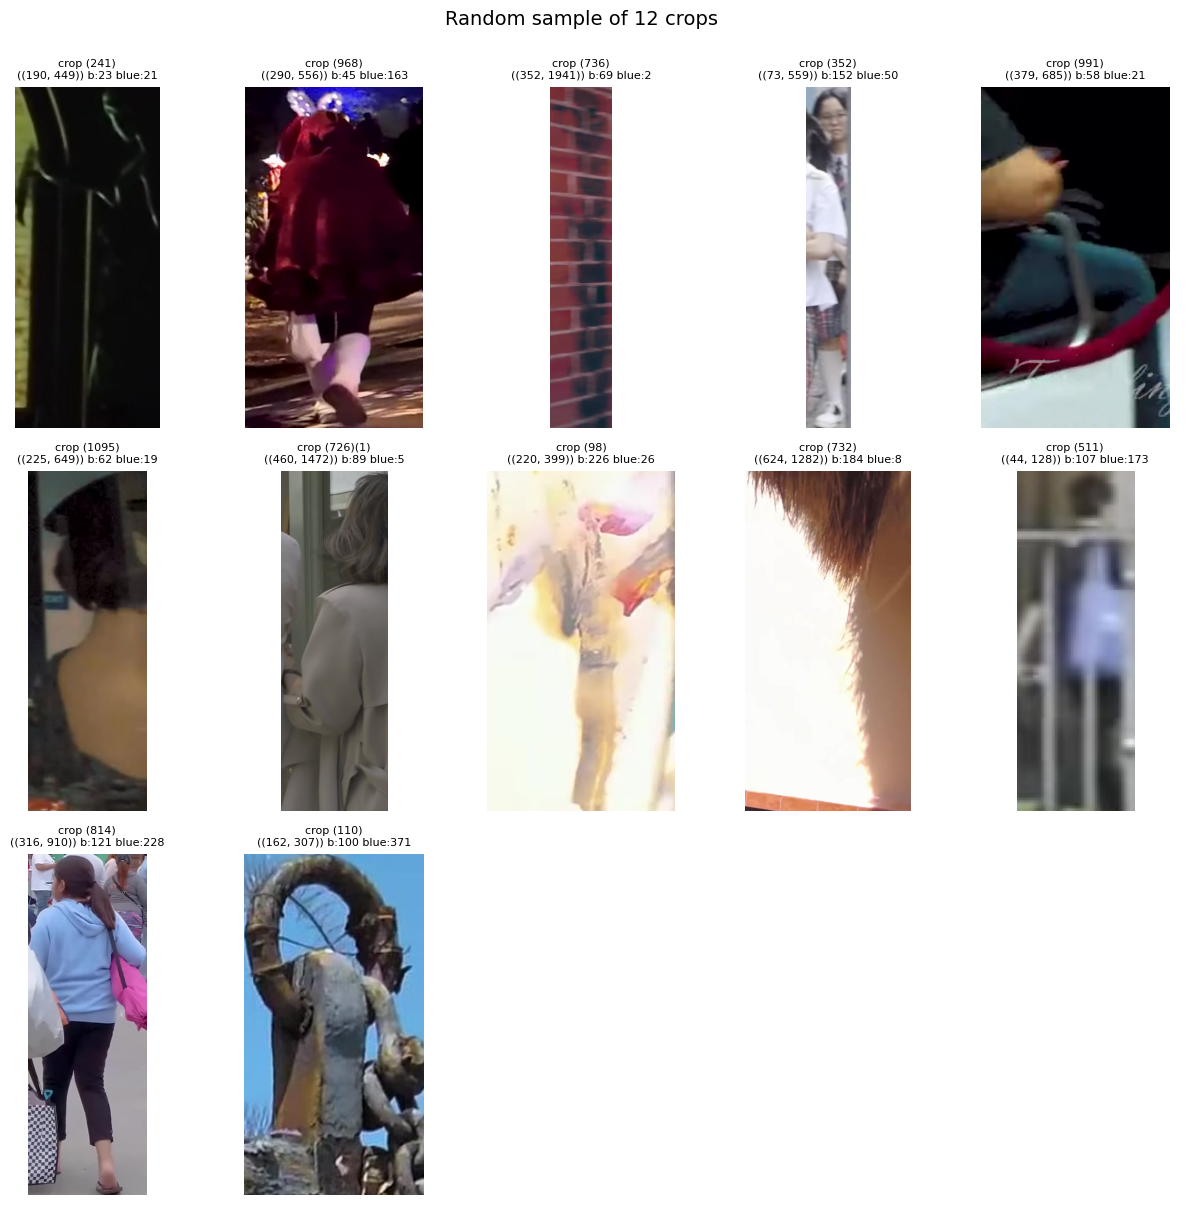

In [8]:
sample = df.sample(n=min(12, len(df)), random_state=42)
show_grid(sample, "Random sample of 12 crops")


In [9]:
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "eda"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

eda_path = ARTIFACTS_DIR / "01_eda_metrics.parquet"
df.to_parquet(eda_path, index=False)
logger.info("Saved EDA metrics")

2026-05-09 11:56:17.778 | INFO     | __main__:<module>:6 - Saved EDA metrics
